## Todo

In [23]:
''' Initialization from scratch

!git clone https://github.com/Skyepulse/HacktionPotential1.git
%cd HacktionPotential1
!ls

!pip install huggingface_hub


#%cd MIRepNet
!ls
#!pip install -r req2.txt
# This modifies the req2.txt file to remove the strict SciPy upper limit
!sed -i 's/scipy>=1.10.0,<1.11.0/scipy>=1.10.0/' req2.txt

# Now try installing again!
!pip install -r req2.txt

'''
%cd /content/HacktionPotential1/MIRepNet

/content/HacktionPotential1/MIRepNet


# MIREPnET

In [24]:
# Test installation and imports
import torch
import torchvision
import torchaudio
import numpy as np
import scipy
import mne
import pandas as pd
import sklearn
import matplotlib
import pylsl
import einops
import wandb
import moabb
import tqdm

print("All libraries imported successfully.")

# Check PyTorch device
if torch.cuda.is_available():
    print(f"PyTorch device: cuda ({torch.cuda.get_device_name(0)})")
else:
    print("PyTorch device: cpu")

All libraries imported successfully.
PyTorch device: cuda (Tesla T4)


In [25]:
# Import MiRepNet and sanity check model
import torch
import torch.nn.functional as F
from model.mlm import mlm_mask

# Instantiate model (adjust emb_size, depth, n_classes as needed)
model = mlm_mask(emb_size=256, depth=6, n_classes=3)  # match checkpoint params

# Load pretrained weights if available
pretrained_path = './weight/MIRepNet.pth'
try:
    state_dict = torch.load(pretrained_path, map_location=torch.device('cpu'))
    model.load_state_dict(state_dict, strict=False)  # allow missing/unexpected keys
    print('Pretrained weights loaded to CPU (non-strict).')
except Exception as e:
    print('Could not load pretrained weights:', e)

# Sanity check: forward pass with dummy data
# shape: (batch, channels, samples)
dummy_input = torch.randn(1, 45, 3000)
with torch.no_grad():
    pooled, cls_output = model(dummy_input)
print('Sanity check output:', cls_output)

# print information of the model
#print(model)

Pretrained weights loaded to CPU (non-strict).
Sanity check output: tensor([[ 6.2087, -1.2149, -0.3144]])


/tmp/ipython-input-4205/845414023.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(pretrained_path, map_location=torch.device('cpu'))


In [26]:
import time
batch_size = 10
fake_eeg_data = torch.randn(batch_size, 45, 10000)

# Run inference
model.eval()
with torch.no_grad():
    tic = time.time()
    pooled_features, logits = model(fake_eeg_data)

probabilities = F.softmax(logits, dim=1) # shape (batch_size, n_classe)
predicted_classes = torch.argmax(probabilities, dim=1) # shape (batch_size)
print("duration = ", time.time() - tic)



duration =  7.347179174423218


In [27]:
from torch.utils.data import DataLoader, TensorDataset

# Example shapes
X_train = torch.randn(100, 45, 3000)
y_train = torch.randint(0, 3, (100,))

X_test = torch.randn(20, 45, 3000)
y_test = torch.randint(0, 3, (20,))

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16)


model = mlm_mask(emb_size=256, depth=6, n_classes=3)

state_dict = torch.load('./weight/MIRepNet.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pooled, logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

/tmp/ipython-input-4205/2108863603.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./weight/MIRepNet.pth', map_location='cpu')


In [28]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            _, logits = model(x)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [29]:
for epoch in range(10):  # MIRepNet converges fast
    loss = train_one_epoch(model, train_loader)
    acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1} | Loss {loss:.4f} | Acc {acc:.4f}")

Epoch 1 | Loss 3.3339 | Acc 0.5000
Epoch 2 | Loss 2.0284 | Acc 0.3000
Epoch 3 | Loss 1.5306 | Acc 0.2500
Epoch 4 | Loss 2.0647 | Acc 0.2500
Epoch 5 | Loss 1.9148 | Acc 0.3500


KeyboardInterrupt: 

In [30]:
from google.colab import drive

drive.mount('/content/drive')
ROOT = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/BNCI2014004"

X = np.load(f"{ROOT}/X.npy")
y = np.load(f"{ROOT}/labels.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)


Mounted at /content/drive
X shape: (1400, 3, 1000)
y shape: (1400,)


In [32]:
!python finetune.py --dataset_name BNCI2014004 --model_name MIRepNet --epochs 2

Starting EEG Classification with Configurable Hyperparameters

Traceback (most recent call last):
  File "/content/HacktionPotential1/MIRepNet/finetune.py", line 74, in <module>
    run_experiment(args, log_file)
  File "/content/HacktionPotential1/MIRepNet/utils/utils.py", line 208, in run_experiment
    val_acc = train_subject(args, subject, seed, device, log_file)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/HacktionPotential1/MIRepNet/utils/utils.py", line 220, in train_subject
    dataset = EEGDataset(args=args)
              ^^^^^^^^^^^^^^^^^^^^^
  File "/content/HacktionPotential1/MIRepNet/dataset.py", line 22, in __init__
    X = np.load('./data/' + self.dataset_name + '/X.npy')
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/npyio.py", line 427, in load
    fid = stack.enter_context(open(os_fspath(file), "rb"))
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^
Fil

Original X shape: (1400, 3, 1000)


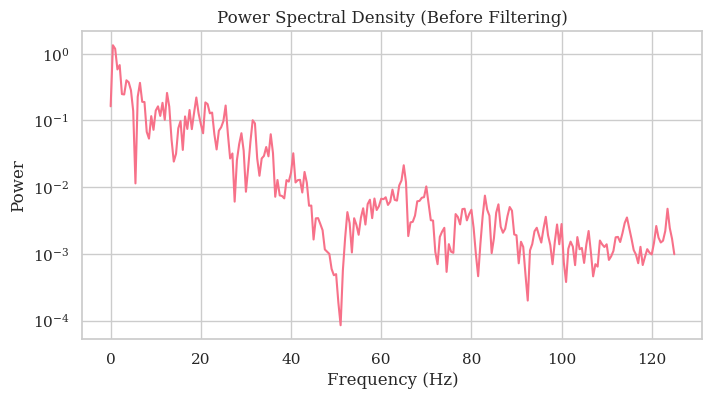

Dominant frequency: 0.5 Hz
Applying 8.0-30.0 Hz bandpass filter...
Applying Euclidean Alignment...
Applying Spatial Interpolation...
Padded X shape: (1400, 45, 1000)
Final PyTorch X shape: (1400, 45, 1000)
unique label = {1: 700, 2: 700}
unique label = {0: 700, 1: 700}
Training on: cuda
Loaded 108/110 parameters from pretrained model


/content/HacktionPotential1/MIRepNet/model/mlm.py:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_dict = torch.load(pretrained_path)


Epoch [1/25] 
Train Loss: 0.7059, Train Acc: 51.25% 
Val Loss: 0.7060, Val Acc: 52.86%
Epoch [6/25] 
Train Loss: 0.6602, Train Acc: 57.95% 
Val Loss: 0.6770, Val Acc: 53.21%
Epoch [11/25] 
Train Loss: 0.6231, Train Acc: 62.14% 
Val Loss: 0.6806, Val Acc: 54.29%
Epoch [16/25] 
Train Loss: 0.6266, Train Acc: 65.27% 
Val Loss: 0.6965, Val Acc: 53.93%
Epoch [21/25] 
Train Loss: 0.6196, Train Acc: 64.38% 
Val Loss: 0.7049, Val Acc: 55.71%


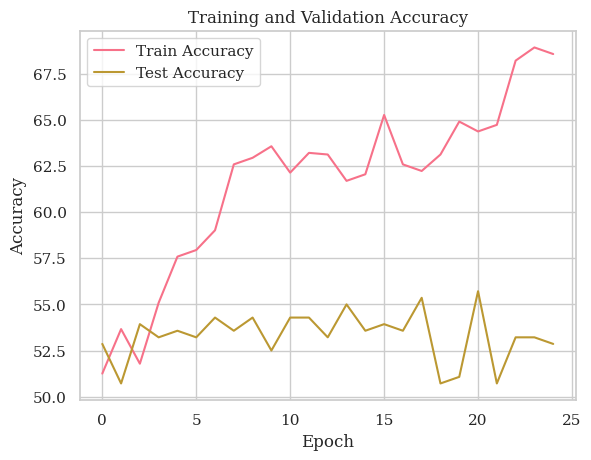

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch
import numpy as np
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import LabelEncoder
import os

# Import the necessary functions from the provided utils
from utils.utils import EA, pad_missing_channels_diff, train, validate
from utils.channel_list import use_channels_names, BNCI2014004_chn_names
from model.mlm import mlm_mask

print("Original X shape:", X.shape) # (1400, 3, 1000)


def inspect_frequency_content(data, fs=250.0):
    """
    data shape: (batch, channels, time)
    """
    # Take one example trial and one channel
    sample = data[0, 0, :]

    freqs, psd = welch(sample, fs=fs, nperseg=fs*2)

    plt.figure(figsize=(8,4))
    plt.semilogy(freqs, psd)
    plt.title("Power Spectral Density (Before Filtering)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    #plt.xlim(0, 60)
    plt.show()

    print("Dominant frequency:", freqs[np.argmax(psd)], "Hz")



def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):

    # current frequency band of the signal
    inspect_frequency_content(data, fs=fs)

    print(f"Applying {lowcut}-{highcut} Hz bandpass filter...")
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    # Filter along the last axis (time)
    return filtfilt(b, a, data, axis=-1)

X_filtered = apply_bandpass(X)



# --- STEP 1: Euclidean Alignment (Distribution Alignment) ---
# This normalizes the covariance across the trials
print("Applying Euclidean Alignment...")
X_ea = EA(X_filtered).astype(np.float32)

# --- STEP 2: Spatial Interpolation ---
# This maps your 3 physical channels (C3, Cz, C4) to the model's 45-channel template
print("Applying Spatial Interpolation...")
X_padded = pad_missing_channels_diff(
    X_ea,
    use_channels_names,     # The 45 target channels the model expects
    BNCI2014004_chn_names   # Your 3 actual channels
)
print("Padded X shape:", X_padded.shape) # Should now be (1400, 45, 1000)

# --- STEP 3: Add Dummy Channel Dimension for PyTorch ---
# The Conv2d layer expects (Batch, Channels, Height, Width) -> (B, 1, 45, 1000)
X_final = X_padded # np.expand_dims(X_padded, axis=1)
print("Final PyTorch X shape:", X_final.shape)

# Encode labels (ensure they start from 0)
unique, count = np.unique(y, return_counts=True)
print("unique label =",dict(zip(unique, count)))
y_encoded = LabelEncoder().fit_transform(y)
#if unique != np.arange(max(unique)):
#  y_encoded = LabelEncoder().fit_transform(y)
print("unique label =",dict(zip(np.unique(y_encoded), count)))



# Split the data (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_final, y_encoded, test_size=0.2, random_state=42)

# Convert numpy arrays to PyTorch Tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Instantiate the Model
model = mlm_mask(
    emb_size=256,
    depth=6,
    n_classes=2,            # BNCI2014004 has 2 classes (Left/Right hand)
    pretrainmode=False,
    pretrain='./weight/MIRepNet.pth' # Path to downloaded weights
).to(device)

# Setup Optimizer, Loss, and Scheduler
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-6)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Training Loop
epochs = 25

train_accuracies, test_accuracies = [], []
for epoch in range(epochs):
    # Use the train/validate functions from utils.py
    train_loss, train_acc, curr_lr = train(model, train_loader, criterion, optimizer, device, scheduler)

    val_loss, val_acc = validate(model, val_loader, criterion, device)

    if epoch % 5 == 0:
      print(f"Epoch [{epoch+1}/{epochs}] \nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% \nVal Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    train_accuracies.append(train_acc)
    test_accuracies.append(val_acc)


plt.figure()
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [43]:
!ls
!ls "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/BNCI2014004"


asset	     LICENSE	  __pycache__  result	    utils
dataset.py   mat_to_X.py  README.md    results.jpg  weight
finetune.py  model	  req2.txt     TESTS.ipynb  weights_download.py


In [66]:
# --- 1. DATA LOADING FUNCTION ---
def extract_trials_from_mat(file_path, trial_length_sec=4, cue_offset_sec=3.0):
    print(f"Loading: {file_path}")
    mat = scipy.io.loadmat(file_path)
    data_struct = mat["data"][0, 0]

    X_raw = data_struct["X"][0, 0][:,:3]  # Grab C3, Cz, C4 channels
    trial_starts = data_struct["trial"][0, 0]
    y_raw = data_struct["y"][0, 0].flatten() # Flatten to 1D array
    fs = int(data_struct["fs"][0, 0])

    trial_length_samples = trial_length_sec * fs
    cue_offset_samples = int(cue_offset_sec * fs) # 3 seconds * 250Hz = 750 samples

    trials = []
    for i in range(len(trial_starts)):
        # Shift the start time to the moment the cue actually appears
        start = trial_starts[i][0] - 1 + cue_offset_samples
        end = start + trial_length_samples

        # Transpose to get (Channels, Time) -> (3, 1000)
        segment = X_raw[start:end, :].T
        trials.append(segment)

    return np.array(trials), y_raw


# --- 2. PREPROCESSING FUNCTION ---
def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

def preprocess_pipeline(X):
    # Bandpass (8-30Hz) -> Euclidean Alignment -> Spatial Interpolation
    X_filt = apply_bandpass(X)
    X_ea = EA(X_filt).astype(np.float32)
    X_padded = pad_missing_channels_diff(
        X_ea,
        use_channels_names,
        BNCI2014004_chn_names
    )
    return X_padded

accuracries_per_subject = []
for subject_idx in range(1,10):
    print(f"\nSubject {subject_idx}")

    # ==========================================
    # EXPERIMENT SETUP
    # ==========================================
    data_dir = ROOT # Update to your Google Drive path if needed
    subject_id = subject_idx  # Pick a subject from 1 to 9

    # Load Train (T) and Eval (E) sets
    train_file = os.path.join(data_dir, f"B0{subject_id}T.mat")
    eval_file = os.path.join(data_dir, f"B0{subject_id}E.mat")

    X_train_raw, y_train_raw = extract_trials_from_mat(train_file)
    X_val_raw, y_val_raw = extract_trials_from_mat(eval_file)

    print(f"\nSubject {subject_id} Train shape: {X_train_raw.shape}")
    print(f"Subject {subject_id} Eval shape: {X_val_raw.shape}")

    # Preprocess the sets
    print("\nPreprocessing Training Set...")
    X_train = preprocess_pipeline(X_train_raw)

    print("Preprocessing Evaluation Set...")
    X_val = preprocess_pipeline(X_val_raw)

    # Encode Labels (Fit on train, apply to both)
    le = LabelEncoder()
    y_train = le.fit_transform(y_train_raw)
    y_val = le.transform(y_val_raw)

    print(X_train.shape)
    print(X_val.shape)
    print(y_train.shape)
    print(y_val.shape)


    # ==========================================
    # PYTORCH SETUP & TRAINING
    # ==========================================
    batch_size = 8
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining on: {device}")

    model = mlm_mask(
        emb_size=256,
        depth=6,
        n_classes=2,
        pretrainmode=False,
        pretrain='./weight/MIRepNet.pth'
    ).to(device)

    # We use a lower Learning Rate since we are fine-tuning on a small, subject-specific dataset
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()
    epochs = 30
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print("\nStarting Subject-Specific Training Loop...")
    for epoch in range(epochs):
        train_loss, train_acc, curr_lr = train(model, train_loader, criterion, optimizer, device, scheduler)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:02d}/{epochs}] "
                  f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}% "
                  f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:5.2f}%")
    accuracries_per_subject.append(val_acc)


print("\nAverage Accuracy:", np.mean(accuracries_per_subject))


Subject 1
Loading: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/BNCI2014004/B01T.mat
Loading: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/BNCI2014004/B01E.mat

Subject 1 Train shape: (120, 3, 1000)
Subject 1 Eval shape: (160, 3, 1000)

Preprocessing Training Set...
Preprocessing Evaluation Set...
(120, 45, 1000)
(160, 45, 1000)
(120,)
(160,)

Training on: cuda
Loaded 108/110 parameters from pretrained model

Starting Subject-Specific Training Loop...
Epoch [01/30] | Train Loss: 0.5785 | Train Acc: 76.67% | Val Loss: 0.5666 | Val Acc: 76.88%
Epoch [10/30] | Train Loss: 0.2512 | Train Acc: 90.83% | Val Loss: 0.4513 | Val Acc: 77.50%
Epoch [20/30] | Train Loss: 0.3203 | Train Acc: 87.50% | Val Loss: 0.6283 | Val Acc: 68.75%
Epoch [30/30] | Train Loss: 0.3647 | Train Acc: 85.00% | Val Loss: 0.5607 | Val Acc: 72.50%

Subject 2
Loading: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/BNCI2014004/B02T.mat
Loading: /content/drive/MyDrive/Colab_Notebooks/Ha

In [69]:
import os
import scipy.io
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import LabelEncoder

# Sklearn / MNE / PyRiemann Imports
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings("ignore")




# --- 1. DATA LOADING FUNCTION ---
def extract_trials_from_mat(file_path, trial_length_sec=4, cue_offset_sec=3.0):
    mat = scipy.io.loadmat(file_path)
    data_struct = mat["data"][0, 0]

    X_raw = data_struct["X"][0, 0][:,:3]  # Grab C3, Cz, C4 channels
    trial_starts = data_struct["trial"][0, 0]
    y_raw = data_struct["y"][0, 0].flatten() # Flatten to 1D array
    fs = int(data_struct["fs"][0, 0])

    trial_length_samples = trial_length_sec * fs
    cue_offset_samples = int(cue_offset_sec * fs) # 3 seconds * 250Hz = 750 samples

    trials = []
    for i in range(len(trial_starts)):
        # Shift the start time to the moment the cue actually appears
        start = trial_starts[i][0] - 1 + cue_offset_samples
        end = start + trial_length_samples

        # Transpose to get (Channels, Time) -> (3, 1000)
        segment = X_raw[start:end, :].T
        trials.append(segment)

    return np.array(trials), y_raw

# --- 2. PREPROCESSING FUNCTION (Bandpass Only for ML) ---
def apply_bandpass(data, lowcut=3.0, highcut=40.0, fs=250.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

# ==========================================
# DEFINE TRADITIONAL ML PIPELINES
# ==========================================
pipelines = {}
# n_components cannot be > 3 because we only have 3 physical channels
pipelines["CSP+LDA"] = make_pipeline(CSP(n_components=3), LDA())

# Using "oas" estimator is safer for low-channel covariances
pipelines["RG+LR"] = make_pipeline(
    Covariances(estimator="oas"),
    TangentSpace(),
    LogisticRegression(solver="lbfgs")
)

pipelines["RG+SVM"] = make_pipeline(
    Covariances(estimator="oas"),
    TangentSpace(),
    SVC(kernel="rbf")
)

# Store results for the final dataframe
all_results = []

# ==========================================
# EXPERIMENT LOOP
# ==========================================
for subject_idx in range(1, 10):
    print(f"\n--- Processing Subject {subject_idx} ---")

    # Load Train (T) and Eval (E) sets
    train_file = os.path.join(ROOT, f"B0{subject_idx}T.mat")
    eval_file = os.path.join(ROOT, f"B0{subject_idx}E.mat")

    X_train_raw, y_train_raw = extract_trials_from_mat(train_file)
    X_val_raw, y_val_raw = extract_trials_from_mat(eval_file)

    # Preprocess (Only Bandpass is needed for traditional ML)
    X_train = apply_bandpass(X_train_raw)
    X_val = apply_bandpass(X_val_raw)

    # Encode Labels
    le = LabelEncoder()
    y_train = le.fit_transform(y_train_raw)
    y_val = le.transform(y_val_raw)

    # Train and evaluate each pipeline
    for pipe_name, pipeline in pipelines.items():
        # Fit on the T session
        pipeline.fit(X_train, y_train)

        # Score on the E session
        accuracy = pipeline.score(X_val, y_val) * 100.0

        print(f"{pipe_name:10s} | Val Acc: {accuracy:.2f}%")

        all_results.append({
            "Subject": subject_idx,
            "Pipeline": pipe_name,
            "Accuracy": accuracy
        })

# ==========================================
# FINAL RESULTS SUMMARY
# ==========================================
df_results = pd.DataFrame(all_results)
summary = df_results.groupby("Pipeline")["Accuracy"].mean().reset_index()

print("\n" + "="*40)
print("FINAL AVERAGE ACCURACY (Across 9 Subjects)")
print("="*40)
for index, row in summary.iterrows():
    print(f"{row['Pipeline']:10s} : {row['Accuracy']:.2f}%")
print("="*40)


--- Processing Subject 1 ---
CSP+LDA    | Val Acc: 66.25%
RG+LR      | Val Acc: 60.62%
RG+SVM     | Val Acc: 56.88%

--- Processing Subject 2 ---
CSP+LDA    | Val Acc: 60.00%
RG+LR      | Val Acc: 55.00%
RG+SVM     | Val Acc: 52.50%

--- Processing Subject 3 ---
CSP+LDA    | Val Acc: 54.37%
RG+LR      | Val Acc: 55.62%
RG+SVM     | Val Acc: 53.12%

--- Processing Subject 4 ---
CSP+LDA    | Val Acc: 93.12%
RG+LR      | Val Acc: 93.12%
RG+SVM     | Val Acc: 92.50%

--- Processing Subject 5 ---
CSP+LDA    | Val Acc: 73.75%
RG+LR      | Val Acc: 63.75%
RG+SVM     | Val Acc: 55.00%

--- Processing Subject 6 ---
CSP+LDA    | Val Acc: 50.00%
RG+LR      | Val Acc: 57.50%
RG+SVM     | Val Acc: 53.75%

--- Processing Subject 7 ---
CSP+LDA    | Val Acc: 68.75%
RG+LR      | Val Acc: 69.38%
RG+SVM     | Val Acc: 63.75%

--- Processing Subject 8 ---
CSP+LDA    | Val Acc: 83.75%
RG+LR      | Val Acc: 83.12%
RG+SVM     | Val Acc: 75.00%

--- Processing Subject 9 ---
CSP+LDA    | Val Acc: 82.50%
RG+LR

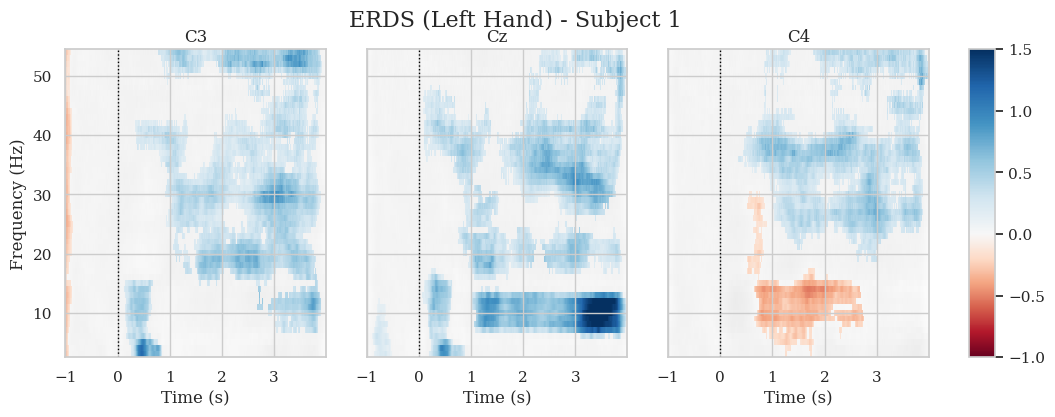

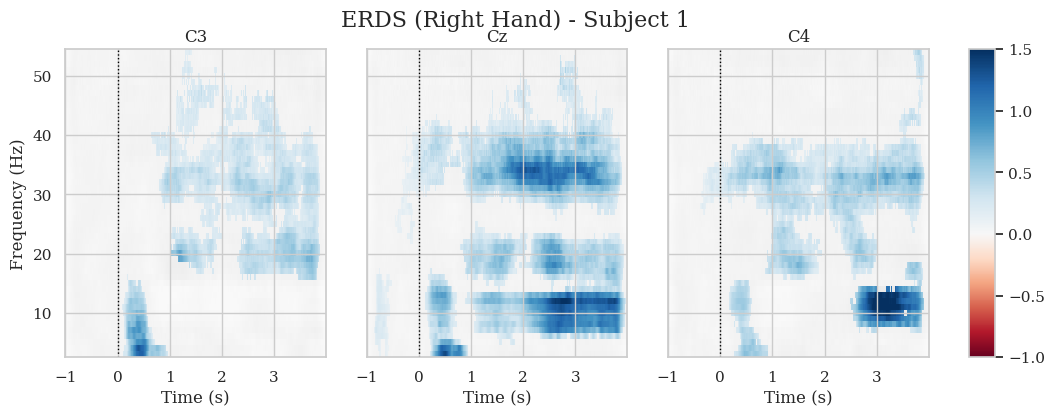

In [71]:
import os
import scipy.io
import numpy as np
import mne
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mne.time_frequency import tfr_multitaper
from mne.stats import permutation_cluster_1samp_test as pcluster_test

# --- 1. EXTRACT DATA WITH A BASELINE ---
def extract_epochs_for_mne(file_path):
    mat = scipy.io.loadmat(file_path)
    data_struct = mat["data"][0, 0]

    X_raw = data_struct["X"][0, 0][:,:3]  # C3, Cz, C4
    trial_starts = data_struct["trial"][0, 0]
    y_raw = data_struct["y"][0, 0].flatten()
    fs = int(data_struct["fs"][0, 0])

    # We want from -1s to +4s relative to the cue (which is at 3s)
    # Absolute time: 2.0s to 7.0s
    start_offset = int(2.0 * fs)
    end_offset = int(7.0 * fs)

    trials = []
    for i in range(len(trial_starts)):
        start = trial_starts[i][0] - 1 + start_offset
        end = trial_starts[i][0] - 1 + end_offset
        # MNE expects (Epochs, Channels, Time)
        segment = X_raw[start:end, :].T
        trials.append(segment)

    return np.array(trials), y_raw

# --- 2. LOAD SUBJECT 1 DATA ---

train_file = os.path.join(ROOT, "B01T.mat")
X_epochs, y_labels = extract_epochs_for_mne(train_file)

# --- 3. CONVERT TO MNE EPOCHS OBJECT ---
ch_names = ['C3', 'Cz', 'C4']
# Multiply by 1e-6 to convert raw microvolts to Volts (MNE's default unit)
X_volts = X_epochs * 1e-6

info = mne.create_info(ch_names=ch_names, sfreq=250.0, ch_types='eeg')
# We tell MNE that time 0.0 is exactly 1 second into our 5-second extracted window
epochs = mne.EpochsArray(X_volts, info, tmin=-1.0)

# Map the numerical labels (1, 2) to class names
event_id = {'Left Hand': 1, 'Right Hand': 2}
epochs.events[:, 2] = y_labels # Inject our labels into MNE's event structure
epochs.event_id = event_id

# --- 4. CALCULATE TIME-FREQUENCY REPRESENTATION (TFR) ---
freqs = np.arange(3, 55) # Focus on Alpha and Beta bands
# Calculate power using multitaper spectral analysis
tfr = tfr_multitaper(
    epochs, freqs=freqs, n_cycles=freqs/2, use_fft=True,
    return_itc=False, average=False, decim=2
)
# Apply baseline correction (compare against the -1s to 0s window)
tfr.crop(-1.0, 4.0).apply_baseline((-1.0, 0.0), mode="percent")

# --- 5. STATISTICAL CLUSTER MASKING & PLOTTING ---
vmin, vmax = -1, 1.5
cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
kwargs = dict(n_permutations=100, step_down_p=0.05, seed=1, buffer_size=None, out_type="mask")

for event in event_id:
    tfr_ev = tfr[event]
    fig, axes = plt.subplots(1, 4, figsize=(12, 4), gridspec_kw={"width_ratios": [10, 10, 10, 1]})

    for ch, ax in enumerate(axes[:-1]):
        # Run statistical tests to find significant ERD/ERS clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch], tail=1, **kwargs)
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch], tail=-1, **kwargs)

        c = np.stack(c1 + c2, axis=2)
        p = np.concatenate((p1, p2))
        mask = c[..., p <= 0.05].any(axis=-1)

        # Plot the ERDS map, applying the statistical mask
        tfr_ev.average().plot(
            [ch], cmap="RdBu", cnorm=cnorm, axes=ax, colorbar=False,
            show=False, mask=mask, mask_style="mask"
        )
        ax.set_title(epochs.ch_names[ch], fontsize=12)
        ax.axvline(0, linewidth=1, color="black", linestyle=":") # Draw cue line
        if ch != 0:
            ax.set_ylabel("")
            ax.set_yticklabels("")

    fig.colorbar(axes[0].images[-1], cax=axes[-1]).ax.set_yscale("linear")
    fig.suptitle(f"ERDS ({event}) - Subject 1", fontsize=16)
    plt.show()

In [72]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

# Sklearn / MNE / PyRiemann Imports
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings("ignore")

ROOT_ = "/content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/"


# ==========================================
# 1. LOAD & FORMAT CUSTOM DATA
# ==========================================
def load_custom_dataset(filepath="mi_dataset.npz"):
    print(f"Loading custom dataset: {filepath}")
    data = np.load(filepath)

    X_raw = data['X']  # Shape: (trials, samples, channels)
    y_raw = data['y']  # Shape: (trials,)
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    print(f"Original X shape: {X_raw.shape}")

    # CRITICAL: Transpose to (Trials, Channels, Time)
    X_transposed = np.transpose(X_raw, (0, 2, 1))
    print(f"Transposed X shape (for ML): {X_transposed.shape}")

    return X_transposed, y_raw, fs

# ==========================================
# 2. PREPROCESSING
# ==========================================
def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
    """Filters data along the time axis (which is now axis -1)"""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

# ==========================================
# 3. DEFINE TRADITIONAL ML PIPELINES
# ==========================================
pipelines = {}

# Since you now have 8 channels, we can safely use 4 components for CSP
# (CSP typically extracts pairs of components, so 4 is standard)
pipelines["CSP+LDA"] = make_pipeline(CSP(n_components=4), LDA())

# Riemannian Geometry pipelines
pipelines["RG+LR"] = make_pipeline(
    Covariances(estimator="oas"),
    TangentSpace(),
    LogisticRegression(solver="lbfgs")
)

pipelines["RG+SVM"] = make_pipeline(
    Covariances(estimator="oas"),
    TangentSpace(),
    SVC(kernel="rbf")
)



# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    # Load and format the data
    X_raw, y_raw, fs = load_custom_dataset(ROOT_+"mi_dataset.npz")

    # Apply 8-30Hz Motor Imagery Filter
    print(f"Applying {8.0}-{30.0} Hz bandpass filter...")
    X_filt = apply_bandpass(X_raw, fs=fs)

    # Encode labels (just to be safe, ensures they are exactly 0 and 1)
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    print(f"Total Trials: {len(y)} (Class 0: {sum(y==0)}, Class 1: {sum(y==1)})")

    # Set up 5-Fold Cross Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    all_results = []

    print("\n" + "="*40)
    print("STARTING 5-FOLD CROSS-VALIDATION")
    print("="*40)

    for pipe_name, pipeline in pipelines.items():
        # cross_val_score handles the fitting and scoring automatically for each fold
        scores = cross_val_score(pipeline, X_filt, y, cv=cv, scoring='accuracy')

        mean_acc = scores.mean() * 100
        std_acc = scores.std() * 100

        print(f"{pipe_name:10s} | Mean Acc: {mean_acc:.2f}% (+/- {std_acc:.2f}%)")

        all_results.append({
            "Pipeline": pipe_name,
            "Accuracy": mean_acc,
            "Std_Dev": std_acc
        })

    # Summary
    print("\n" + "="*40)
    print("FINAL RESULTS")
    print("="*40)
    df_results = pd.DataFrame(all_results)
    df_results = df_results.sort_values(by="Accuracy", ascending=False)
    for index, row in df_results.iterrows():
        print(f"{row['Pipeline']:10s} : {row['Accuracy']:.2f}%")

Loading custom dataset: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/mi_dataset.npz
Original X shape: (60, 1500, 8)
Transposed X shape (for ML): (60, 8, 1500)
Applying 8.0-30.0 Hz bandpass filter...
Total Trials: 60 (Class 0: 30, Class 1: 30)

STARTING 5-FOLD CROSS-VALIDATION
CSP+LDA    | Mean Acc: 66.67% (+/- 11.79%)
RG+LR      | Mean Acc: 76.67% (+/- 11.06%)
RG+SVM     | Mean Acc: 78.33% (+/- 11.30%)

FINAL RESULTS
RG+SVM     : 78.33%
RG+LR      : 76.67%
CSP+LDA    : 66.67%


In [76]:


import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from scipy.signal import butter, filtfilt

# Import the necessary functions from MIRepNet utils
from utils.utils import EA, pad_missing_channels_diff, train, validate
from utils.channel_list import use_channels_names
from model.mlm import mlm_mask

# --- 1. CUSTOM DATA LOADING FUNCTION ---
def load_custom_dataset(filepath="mi_dataset.npz"):
    print(f"Loading custom dataset: {filepath}")
    data = np.load(filepath)

    X_raw = data['X']  # LSL saves as (Trials, Time, Channels)
    y_raw = data['y']  # (Trials,)
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    # CRITICAL: Transpose to (Trials, Channels, Time) for PyTorch/EA
    X_transposed = np.transpose(X_raw, (0, 2, 1))
    return X_transposed, y_raw, fs

# --- 2. PREPROCESSING FUNCTIONS ---
def apply_bandpass(data, lowcut=8.0, highcut=30.0, fs=250.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

# ==========================================
# EXPERIMENT SETUP
# ==========================================
if __name__ == "__main__":
    # 1. Load your custom data
    X_raw, y_raw, fs = load_custom_dataset(ROOT_+"mi_dataset.npz")

    # Encode Labels
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    # 2. DEFINE YOUR HEADSET CHANNELS HERE!
    # These must match the names in `utils.channel_list` dictionary
    # Example placeholder: (Please update to your actual 8 electrodes)
    MY_8_CHANNELS = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']

    # 3. Preprocess the entire dataset (Filter -> EA -> Interpolate)
    print("\nPreprocessing Entire Dataset...")
    X_filt = apply_bandpass(X_raw, fs=fs)
    X_ea = EA(X_filt).astype(np.float32)
    X_padded = pad_missing_channels_diff(
        X_ea,
        use_channels_names, # The 45 target template channels
        MY_8_CHANNELS       # Your 8 actual physical channels
    )

    print(f"Final Data Shape for Model: {X_padded.shape}")

    # ==========================================
    # CROSS-VALIDATION & PYTORCH TRAINING
    # ==========================================
    n_splits = 5
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining on: {device}")

    batch_size = 8
    epochs = 30
    accuracies_per_fold = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_padded, y)):
        print(f"\n" + "="*30)
        print(f"=== Fold {fold+1}/{n_splits} ===")
        print("="*30)

        # Split data for this fold
        X_train, X_val = X_padded[train_idx], X_padded[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Create DataLoaders
        train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
        val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # CRITICAL: Re-instantiate the model, optimizer, and scheduler inside the loop
        # so each fold starts fresh from the pretrained weights!
        model = mlm_mask(
            emb_size=256,
            depth=6,
            n_classes=2,
            pretrainmode=False,
            pretrain='./weight/MIRepNet.pth'
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        final_val_acc = 0.0

        # Training Loop for this Fold
        for epoch in range(epochs):
            train_loss, train_acc, curr_lr = train(model, train_loader, criterion, optimizer, device, scheduler)
            val_loss, val_acc = validate(model, val_loader, criterion, device)

            final_val_acc = val_acc # Track the last epoch's accuracy

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"Epoch [{epoch+1:02d}/{epochs}] "
                      f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}% "
                      f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:5.2f}%")

        accuracies_per_fold.append(final_val_acc)
        print(f"Fold {fold+1} Completed. Validation Accuracy: {final_val_acc:.2f}%")

    # ==========================================
    # FINAL RESULTS
    # ==========================================
    print("\n" + "="*40)
    print("FINAL 5-FOLD CROSS-VALIDATION RESULTS")
    print("="*40)
    for i, acc in enumerate(accuracies_per_fold):
        print(f"Fold {i+1}: {acc:.2f}%")
    print("-" * 40)
    print(f"Average Accuracy: {np.mean(accuracies_per_fold):.2f}% (+/- {np.std(accuracies_per_fold):.2f}%)")
    print("="*40)

Loading custom dataset: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/mi_dataset.npz

Preprocessing Entire Dataset...
Final Data Shape for Model: (60, 45, 1500)

Training on: cuda

=== Fold 1/5 ===
Loaded 108/110 parameters from pretrained model
Epoch [01/30] | Train Loss: 0.6961 | Train Acc: 50.00% | Val Loss: 0.6831 | Val Acc: 58.33%
Epoch [10/30] | Train Loss: 0.6629 | Train Acc: 54.17% | Val Loss: 0.7509 | Val Acc: 33.33%
Epoch [20/30] | Train Loss: 0.6146 | Train Acc: 68.75% | Val Loss: 0.8348 | Val Acc: 41.67%
Epoch [30/30] | Train Loss: 0.5828 | Train Acc: 68.75% | Val Loss: 0.8539 | Val Acc: 41.67%
Fold 1 Completed. Validation Accuracy: 41.67%

=== Fold 2/5 ===
Loaded 108/110 parameters from pretrained model
Epoch [01/30] | Train Loss: 0.7011 | Train Acc: 47.92% | Val Loss: 0.6832 | Val Acc: 83.33%
Epoch [10/30] | Train Loss: 0.6735 | Train Acc: 56.25% | Val Loss: 0.6979 | Val Acc: 58.33%
Epoch [20/30] | Train Loss: 0.6252 | Train Acc: 64.58% | Val Loss: 0.7052 | Va

Loading custom dataset: /content/drive/MyDrive/Colab_Notebooks/Hacktion_Potential/mi_dataset.npz
Rest array shape: (60, 1500, 8)
MI array shape: (60, 1500, 8)
Filtering out DC offset and artifacts...
Calculating Time-Frequency Representation...


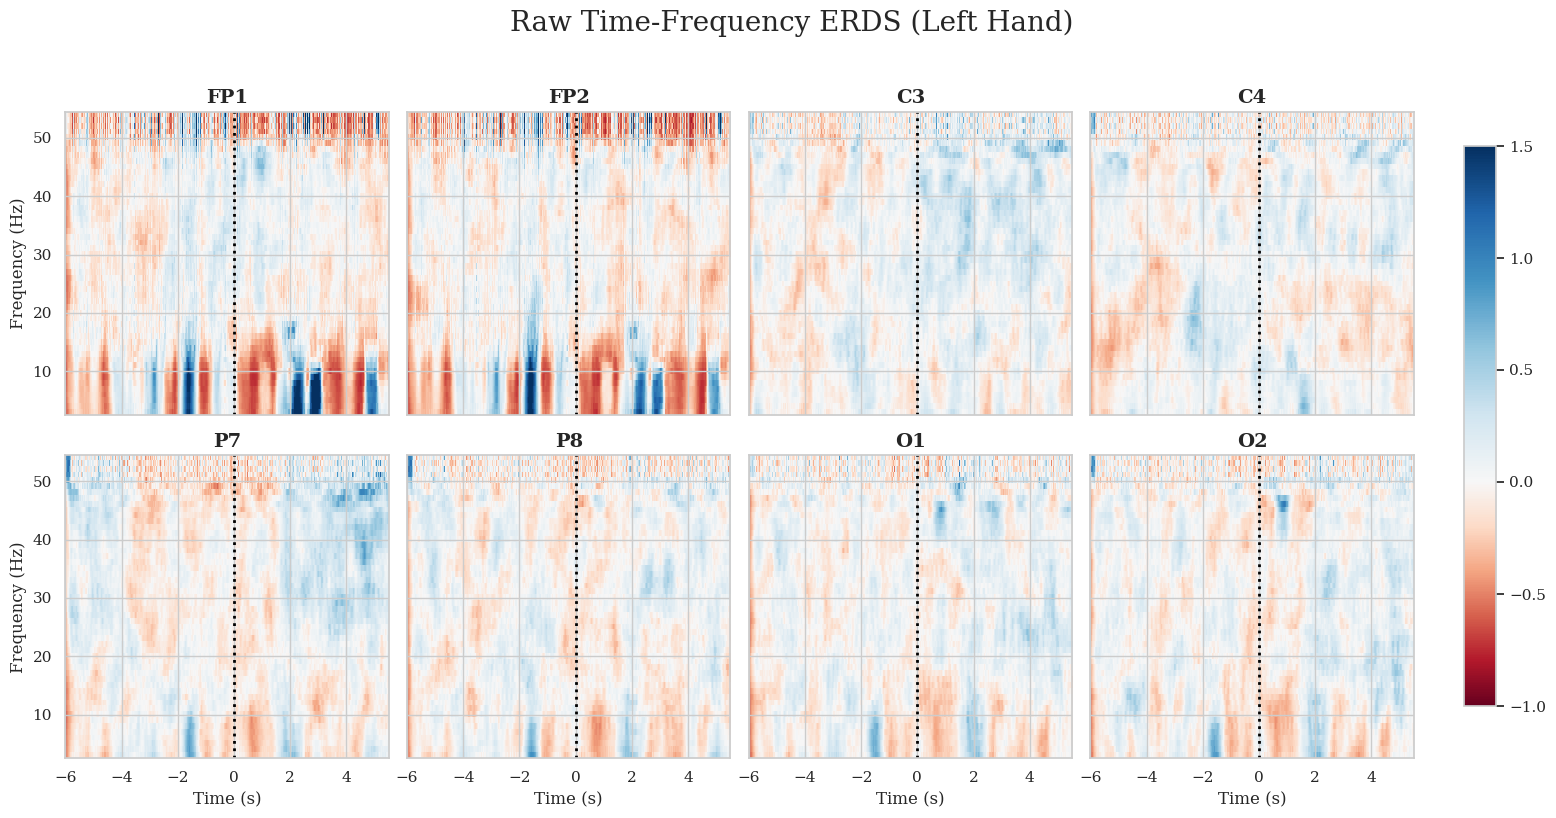

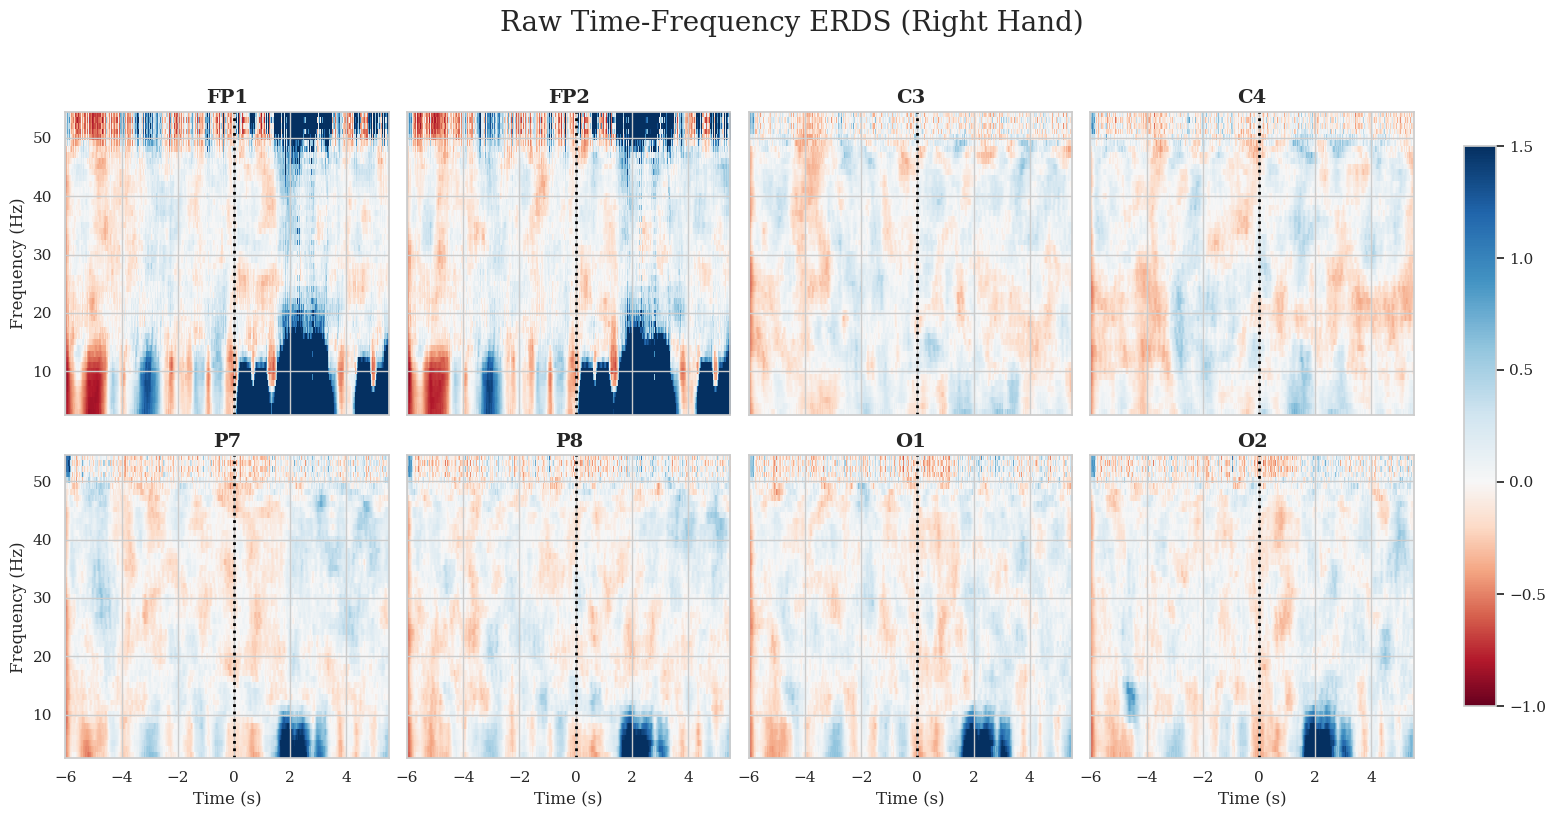

In [83]:
import numpy as np
import mne
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mne.time_frequency import tfr_multitaper

# --- 1. LOAD CUSTOM 8-CHANNEL DATA AND STITCH TIMELINE ---
def load_custom_for_mne(filepath="mi_dataset.npz"):
    print(f"Loading custom dataset: {filepath}")
    data = np.load(filepath)

    X_mi = data['X']   # Shape: (Trials, Time_MI, Channels)
    X_rest = data['z'] # Shape: (Trials, Time_Rest, Channels)
    y_raw = data['y']
    fs = data['fs'].item() if data['fs'].size == 1 else data['fs'][0]

    print(f"Rest array shape: {X_rest.shape}")
    print(f"MI array shape: {X_mi.shape}")

    # STITCHING: Combine Rest and MI along the time axis (axis 1)
    # This creates a continuous timeline: [ --- Rest --- | --- MI --- ]
    X_full = np.concatenate([X_rest, X_mi], axis=1)

    # Transpose to MNE format: (Trials, Channels, Time)
    X_full = np.transpose(X_full, (0, 2, 1))

    # Calculate exactly when the cue happens (Time 0.0) based on the rest duration
    rest_samples = X_rest.shape[1]
    tmin = -(rest_samples / fs) # e.g., if rest was 6 seconds, tmin is -6.0
    tmax = X_mi.shape[1] / fs   # e.g., if MI was 6 seconds, tmax is 6.0

    return X_full, y_raw, fs, tmin, tmax

# Load the data
X_epochs, y_labels, fs, tmin, tmax = load_custom_for_mne(ROOT_+"mi_dataset.npz")

# --- 2. CONVERT TO MNE EPOCHS OBJECT ---
ch_names = ['FP1', 'FP2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']

# Multiply by 1e-6 to convert raw microvolts to Volts (MNE's standard)
X_volts = X_epochs * 1e-6

info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types='eeg')
epochs = mne.EpochsArray(X_volts, info, tmin=tmin)

# Map your labels (0=LEFT, 1=RIGHT)
event_id = {'Left Hand': 0, 'Right Hand': 1}
epochs.events[:, 2] = y_labels
epochs.event_id = event_id


# ==========================================
# THE FIX: Apply the Bandpass Filter Here!
# ==========================================
print("Filtering out DC offset and artifacts...")
epochs.filter(l_freq=5.0, h_freq=40.0)
# ==========================================

# --- 3. CALCULATE TIME-FREQUENCY REPRESENTATION (TFR) ---
print("Calculating Time-Frequency Representation...")
freqs = np.arange(3, 55) # 3 Hz to 55 Hz
tfr = tfr_multitaper(
    epochs, freqs=freqs, n_cycles=freqs/2, use_fft=True,
    return_itc=False, average=False, decim=2
)

# Apply baseline correction (using the rest period: from tmin to 0.0)
# We crop slightly before tmax to avoid edge artifacts
tfr.crop(tmin, tmax - 0.5).apply_baseline((tmin, 0.0), mode="percent")

# --- 4. PLOTTING 8 CHANNELS (UNMASKED SPECTROGRAM) ---
vmin, vmax = -1, 1.5
cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

for event in event_id:
    # Average the trials for this specific condition
    tfr_ev = tfr[event].average()

    # Create a 2x4 grid for our 8 channels
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for ch, ax in enumerate(axes):
        # Plot the ERDS map for this channel
        img = tfr_ev.plot(
            [ch], cmap="RdBu", cnorm=cnorm, axes=ax, colorbar=False, show=False
        )
        ax.set_title(epochs.ch_names[ch], fontsize=14, fontweight='bold')

        # Draw the cue line (Time = 0.0)
        ax.axvline(0, linewidth=2, color="black", linestyle=":")

        # Clean up labels so it's not too cluttered
        if ch % 4 != 0: # Only show Y-axis (Frequency) on the left-most plots
            ax.set_ylabel("")
            ax.set_yticklabels("")
        if ch < 4:      # Only show X-axis (Time) on the bottom row
            ax.set_xlabel("")
            ax.set_xticklabels("")

    # Add a single colorbar for the whole figure
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
    fig.colorbar(axes[0].images[-1], cax=cbar_ax).ax.set_yscale("linear")

    fig.suptitle(f"Raw Time-Frequency ERDS ({event})", fontsize=20, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Leave room for the colorbar
    plt.show()